# 숙제 3

데이터과학 입문

장재은 (서울대학교 통계학과)  
0615 2026

## 지시사항

제출마감 2026-06-15 23:00

1.  R과 Python을 모두 사용하여 사용된 코드와 데이터랭글링 절차,
    분석결과를 설명한다. 두 언어의 분석결과가 차이가 있으면 그 이유를
    설명한다.
2.  [Quarto
    Markdown](https://quarto.org/docs/authoring/markdown-basics.html)을
    사용한다. 제공된 숙제 `.qmd` 파일에 본인의 답안을 “답안” 절에
    추가하여 제출한다. Quarto Markdown은 RStudio 또는 Visual Studio
    Code에 [Quarto
    Extension](https://marketplace.visualstudio.com/items?itemName=quarto.quarto)을
    추가하여 컴파일, 다른 문서 형식으로 변환할 수 있다.
3.  R의 `reticulate` 패키지를 사용하면 하나의 `.qmd` 파일 안에서 R과
    Python을 동시에 사용할 수 있다. 이때 다음 문법을 사용하여 두 언어
    코드를 탭으로 구분한다. 숙제 `.qmd` 파일은 `reticulate`을 사용하도록
    준비되어 있다.

```` markdown

::: {.panel-tabset}

## R


::: {.cell layout-align="center"}

:::


## Python

```{python}
Python code
```

:::
````

1.  `.qmd`를 컴파일하여 생성된 `.html` 파일을 함께 저장소에 제출한다.
2.  함께 제공된 `student.yml`을 함께 작성하여 저장소에 제출한다.

## 평가 기준

1.  재현성: 제출된 저장소의 `.qmd` 파일을 컴파일하여 함께 제출된 `.html`
    파일과 동일한 결과가 나와야 한다.
2.  분석의 정확성: 분석은 올바른 기술적 세부 사항을 포함하여 수행되어야
    한다.
3.  보고서의 전반적인 품질: 데이터 가공 및 분석 결과가 명확하고 자세하게
    설명되어야 한다.
4.  코드의 전반적인 품질: 코드는 체계적으로 정리되어 있어야 하며,
    가독성을 높이기 위해 적절한 주석이 포함되어야 한다.

#### **늦게 제출된 과제물은 받지 않는다.**

## R

``` r
# install.packages("tidyverse")
# install.packages("mdsr")
# install.packages("lubridate")
# install.packages("Lahman")
# install.packages("googlesheets4")
# install.packages("babynames")
# install.packages("rvest")
library("ggplot2")
library("lubridate")
library("Lahman")
library(tidyverse)
library(mdsr)
library(googlesheets4)
library(babynames)
library(rvest)
library(bench)
library(NHANES)
library(patchwork)
library(mosaicData)

sessionInfo()
```

    R version 4.6.0 (2026-04-24)
    Platform: x86_64-pc-linux-gnu
    Running under: Ubuntu 24.04.4 LTS

    Matrix products: default
    BLAS:   /usr/lib/x86_64-linux-gnu/openblas-pthread/libblas.so.3 
    LAPACK: /usr/lib/x86_64-linux-gnu/openblas-pthread/libopenblasp-r0.3.26.so;  LAPACK version 3.12.0

    locale:
     [1] LC_CTYPE=C.UTF-8       LC_NUMERIC=C           LC_TIME=C.UTF-8       
     [4] LC_COLLATE=C.UTF-8     LC_MONETARY=C.UTF-8    LC_MESSAGES=C.UTF-8   
     [7] LC_PAPER=C.UTF-8       LC_NAME=C              LC_ADDRESS=C          
    [10] LC_TELEPHONE=C         LC_MEASUREMENT=C.UTF-8 LC_IDENTIFICATION=C   

    time zone: UTC
    tzcode source: system (glibc)

    attached base packages:
    [1] stats     graphics  grDevices utils     datasets  methods   base     

    other attached packages:
     [1] mosaicData_0.20.4   patchwork_1.3.2     NHANES_2.1.0       
     [4] bench_1.1.4         rvest_1.0.5         babynames_1.0.1    
     [7] googlesheets4_1.1.2 mdsr_0.2.9          forcats_1.0.1      
    [10] stringr_1.6.0       dplyr_1.2.1         purrr_1.2.2        
    [13] readr_2.2.0         tidyr_1.3.2         tibble_3.3.1       
    [16] tidyverse_2.0.0     Lahman_14.0-0       lubridate_1.9.5    
    [19] ggplot2_4.0.3       reticulate_1.46.0   knitr_1.51         

    loaded via a namespace (and not attached):
     [1] gtable_0.3.6       xfun_0.58          websocket_1.4.4    processx_3.9.0    
     [5] gargle_1.6.1       lattice_0.22-9     tzdb_0.5.0         vctrs_0.7.3       
     [9] tools_4.6.0        ps_1.9.3           generics_0.1.4     pkgconfig_2.0.3   
    [13] Matrix_1.7-5       RColorBrewer_1.1-3 skimr_2.2.2        S7_0.2.2          
    [17] lifecycle_1.0.5    compiler_4.6.0     farver_2.1.2       chromote_0.5.1    
    [21] repr_1.1.7         htmltools_0.5.9    yaml_2.3.12        pillar_1.11.1     
    [25] later_1.4.8        tidyselect_1.2.1   digest_0.6.39      stringi_1.8.7     
    [29] fastmap_1.2.0      grid_4.6.0         cli_3.6.6          magrittr_2.0.5    
    [33] base64enc_0.1-6    withr_3.0.2        scales_1.4.0       promises_1.5.0    
    [37] googledrive_2.1.2  timechange_0.4.0   rmarkdown_2.31     httr_1.4.8        
    [41] otel_0.2.0         cellranger_1.1.0   png_0.1-9          hms_1.1.4         
    [45] evaluate_1.0.5     rlang_1.2.0        Rcpp_1.1.1-1.1     glue_1.8.1        
    [49] xml2_1.5.2         jsonlite_2.0.0     R6_2.6.1           fs_2.1.0          

## Python

``` python
#!pip install session-info
# !pip install polars
# !pip install pylahman
# !pip install pybabynames
import session_info
import requests
import io
import polars as pl
import pandas as pd
import numpy as np
import pybabynames as bn
from plotnine import *
import zipfile
from datetime import datetime
from bs4 import BeautifulSoup
import matplotlib.pyplot as plt
import patchworklib as pw
from IPython.display import Image
from scipy import stats
from scipy.optimize import curve_fit, least_squares, minimize

import seaborn as sns
#import sympy as sp
import os
from patsy.contrasts import Poly

import pylahman
from plotnine import *
import statsmodels
import statsmodels.api as sm
import statsmodels.formula.api as smf

session_info.show()
```

    -----
    IPython             8.37.0
    bs4                 4.15.0
    matplotlib          3.10.9
    numpy               2.2.6
    pandas              2.3.3
    patchworklib        0.6.6
    patsy               1.0.2
    plotnine            0.15.5
    polars              1.41.2
    pybabynames         NA
    pylahman            NA
    requests            2.34.2
    scipy               1.15.2
    seaborn             0.13.2
    session_info        1.0.0
    statsmodels         0.14.6
    -----
    Python 3.10.20 | packaged by conda-forge | (main, Mar  5 2026, 16:53:43) [GCC 14.3.0]
    Linux-6.17.0-1015-azure-x86_64-with-glibc2.39
    -----
    Session information updated at 2026-06-10 05:35

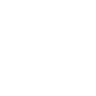

# 1부 교과서 연습문제

## 문제 1-1

1.  MDSR 10장 연습문제 10.6.6

### 답안

Use the NHANES data from the NHANES package to develop a logistic
regression model that identifies predictors of current smoking among
those 20 or older. (Hint: note that the SmokeNow variable is missing for
those who have never smoked: you will need to recode the variable to
construct your outcome variable.)

# Choosing candidates for predictors

First, since labels NA for those who have never smoked, I converted NA
to 0.

Then, I choose the following variables as my potential predictors.

## 7 Candidate variables (with short explanations):

1.  Age — People are more likely to smoke at certain ages than others  
2.  Poverty — More exposure to people who smoke around you  
3.  Marijuana — If yes, less prone to choosing cigarettes over
    marijuana  
4.  Hard drugs — If yes, less prone to choosing cigarettes over hard
    drugs  
5.  Gender — Cultural norms may make women less likely to smoke  
6.  Marital status — Less likely to smoke in consideration for their
    children

Therefore, say

$$\log\left(\frac{p}{1-p}\right) = \beta_0 
+ \beta_1\text{Age} 
+ \beta_2\text{Poverty} 
+ \beta_3\text{Marijuana}_{\text{Yes}} 
+ \beta_4\text{HardDrugs}_{\text{Yes}} 
+ \beta_5\text{Gender}_{\text{female}} 
+ \beta_6\text{MS}_{\text{Married}} 
+ \beta_7\text{MS}_{\text{Divorced}} 
+ \beta_8\text{MS}_{\text{LivePartner}} 
+ \beta_9\text{MS}_{\text{Separated}} 
+ \beta_{10}\text{MS}_{\text{Widowed}}$$

where $p = P(\text{SmokeNow} = 1)$ and $\text{MS}$ denotes
MaritalStatus, with as the reference category.

We test:

$$H_0: \beta_1 = \beta_2 = \cdots = \beta_{10} = 0$$

$$H_1: \text{at least one } \beta_k \neq 0, \quad k = 1, \ldots, 10$$

First, we fit a logistic regression to these variables and proceed to
model selection.

# Model Selection

After checking that the null hypothesis is rejected via stepAIC, we
further test whether the interaction terms improve model fit:

$$H_0: \text{final model} = \text{base model (no interactions)}$$

$$H_1: \text{at least one interaction term } \beta_k \neq 0$$ Therefore,
we get the final model:

$$\begin{aligned}
\log\left(\frac{p}{1-p}\right)
=&\ \beta_0
+\beta_1\text{Age}
+\beta_2\text{Poverty}
+\beta_3\text{Marijuana}_{\text{Yes}}
+\beta_4\text{HardDrugs}_{\text{Yes}}
+\beta_5\text{Gender}_{\text{female}} \\
&+\beta_6\text{MS}_{\text{Divorced}}
+\beta_7(\text{Age}\times\text{MS}_{\text{Divorced}})
+\beta_8(\text{Marijuana}_{\text{Yes}}\times\text{Gender}_{\text{female}}) \\
&+\beta_9(\text{Age}\times\text{Marijuana}_{\text{Yes}})
+\beta_{10}(\text{Gender}_{\text{female}}\times\text{MS}_{\text{Divorced}})
+\beta_{11}(\text{Gender}_{\text{female}}\times\text{MS}_{\text{Widowed}}) \\
&+\beta_{12}(\text{Poverty}\times\text{MS}_{\text{Widowed}})
+\beta_{13}(\text{HardDrugs}_{\text{Yes}}\times\text{Gender}_{\text{female}})
+\beta_{14}(\text{Poverty}\times\text{Marijuana}_{\text{Yes}}) \\
&+\beta_{15}(\text{Poverty}\times\text{Gender}_{\text{female}}).
\end{aligned}$$
The final model was selected using AIC-based stepwise selection. The
retained terms are shown in the output below. The python model
additionally included “Live Partner” for Marital status and the
interaction term between poverty and married.

The python implementation result is different because it uses a
backward-elimination procedure that is different from R’s stepAIC().

## R

``` r
#mosaic::tally(~ SmokeNow + Smoke100, data = filter(NHANES, Age >= 20))
write.csv("NHANES.csv")
```

    "","x"
    "1","NHANES.csv"

``` r
# Detect if any age is missing table(df$Age, useNA="ifany")
df_0 <- NHANES |>
  filter(Age >= 20)

#glimpse(df_0)

# 2) Select variables
df <- NHANES |>
  filter(Age >= 20) |>
  mutate(
    SmokeNow_new = ifelse(is.na(SmokeNow) | SmokeNow != "Yes", 0, 1),
    
    Marijuana = factor(Marijuana, levels = c("No", "Yes")),
    HardDrugs = factor(HardDrugs, levels = c("No", "Yes")),  
    Gender = factor(Gender, levels = c("male", "female")),
    MaritalStatus = factor(MaritalStatus,
                       levels = c("NeverMarried", "Married", "Divorced", 
                                  "LivePartner", "Separated", "Widowed")) 
  ) |>
  select(SmokeNow_new, Age, Poverty, Marijuana, HardDrugs, 
        Gender, MaritalStatus) |>
  drop_na()

##################################
# BASE MODEL: Logistic regression
##################################
is_smoker_glm <- glm(SmokeNow_new ~ ., family = binomial, data = df)
summary(is_smoker_glm,  cor = F)
```


    Call:
    glm(formula = SmokeNow_new ~ ., family = binomial, data = df)

    Coefficients:
                              Estimate Std. Error z value Pr(>|z|)    
    (Intercept)              -1.357647   0.161675  -8.397  < 2e-16 ***
    Age                       0.007480   0.003963   1.887 0.059117 .  
    Poverty                  -0.348061   0.025464 -13.669  < 2e-16 ***
    MarijuanaYes              1.157701   0.096661  11.977  < 2e-16 ***
    HardDrugsYes              0.667867   0.092421   7.226 4.96e-13 ***
    Genderfemale             -0.142707   0.079193  -1.802 0.071541 .  
    MaritalStatusMarried     -0.375631   0.106277  -3.534 0.000409 ***
    MaritalStatusDivorced     0.102488   0.146981   0.697 0.485621    
    MaritalStatusLivePartner  0.734100   0.129622   5.663 1.48e-08 ***
    MaritalStatusSeparated    0.015402   0.233815   0.066 0.947480    
    MaritalStatusWidowed      0.242572   0.347940   0.697 0.485698    
    ---
    Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

    (Dispersion parameter for binomial family taken to be 1)

        Null deviance: 4811.0  on 4423  degrees of freedom
    Residual deviance: 4089.6  on 4413  degrees of freedom
    AIC: 4111.6

    Number of Fisher Scoring iterations: 5

``` r
#################################
# MODEL SELECTION
#################################

# 1) Backward selection for main effects 
is_smoker_step <- MASS::stepAIC(is_smoker_glm, trace=F)
#is_smoker_step$anova

# 2) Search for interactions / nonlinear age effect
is_smoker_step2 <- MASS::stepAIC(is_smoker_glm, ~.^2 +
                                   I(scale(Age)^2), trace = F)
#is_smoker_step2$anova

# 3) Find significant coefficients at 0.05 level
summary(is_smoker_step2)$coefficients |>
  as.data.frame() |>
  filter(`Pr(>|z|)` < 0.05)
```

                                          Estimate  Std. Error   z value
    (Intercept)                        -2.82713839 0.417886705 -6.765323
    Age                                 0.04793334 0.011031004  4.345329
    MarijuanaYes                        1.93043535 0.355252170  5.433986
    HardDrugsYes                        0.91107043 0.124362313  7.325937
    Genderfemale                       -0.96087368 0.235765975 -4.075540
    MaritalStatusDivorced               2.17756469 0.719154584  3.027951
    Age:MaritalStatusDivorced          -0.05909200 0.014693934 -4.021523
    MarijuanaYes:Genderfemale           0.82218397 0.196957001  4.174434
    Age:MarijuanaYes                   -0.02040207 0.008245989 -2.474181
    Genderfemale:MaritalStatusDivorced  0.70799924 0.277554763  2.550845
    Genderfemale:MaritalStatusWidowed  -3.04688806 1.308815727 -2.327973
    Poverty:MaritalStatusWidowed       -1.51168954 0.581455831 -2.599836
    HardDrugsYes:Genderfemale          -0.49801765 0.193008693 -2.580286
    Poverty:MarijuanaYes               -0.15577779 0.058809620 -2.648849
    Poverty:Genderfemale                0.10084529 0.050934316  1.979909
                                           Pr(>|z|)
    (Intercept)                        1.330125e-11
    Age                                1.390674e-05
    MarijuanaYes                       5.510888e-08
    HardDrugsYes                       2.372357e-13
    Genderfemale                       4.590767e-05
    MaritalStatusDivorced              2.462182e-03
    Age:MaritalStatusDivorced          5.782296e-05
    MarijuanaYes:Genderfemale          2.987280e-05
    Age:MarijuanaYes                   1.335421e-02
    Genderfemale:MaritalStatusDivorced 1.074620e-02
    Genderfemale:MaritalStatusWidowed  1.991352e-02
    Poverty:MaritalStatusWidowed       9.326845e-03
    HardDrugsYes:Genderfemale          9.871849e-03
    Poverty:MarijuanaYes               8.076645e-03
    Poverty:Genderfemale               4.771380e-02

## Python

``` python
df_pd = pd.read_csv("NHANES.csv")

# filter age >=20
df_0 = (pl.from_pandas(df_pd)
  .filter(pl.col("Age") >= 20)
)

# Check what variables are available
#df_0.head() # in Python
# Choose variables
cols = ["SmokeNow_new", "Age", "Poverty",
        "Marijuana", "HardDrugs", "Gender", "MaritalStatus"]
df_pd["MaritalStatus"].value_counts(dropna=False)
```

    MaritalStatus
    Married         3945
    NaN             2769
    NeverMarried    1380
    Divorced         707
    LivePartner      560
    Widowed          456
    Separated        183
    Name: count, dtype: int64

``` python
smoke_pl = (
    pl.from_pandas(df_pd)
    .filter(pl.col("Age") >= 20)
    .with_columns([

        pl.when(pl.col("SmokeNow") == "Yes").then(1)
          .otherwise(0)   
          .alias("SmokeNow_new"),
          
        # ---- categorical variables ----
        pl.when(pl.col("Marijuana").is_in(["No", "Yes"]))
          .then(pl.col("Marijuana"))
          .otherwise(None)
          .cast(pl.Enum(["No", "Yes"])),          
        
        pl.when(pl.col("HardDrugs").is_in(["No", "Yes"]))
          .then(pl.col("HardDrugs"))
          .otherwise(None)
          .cast(pl.Enum(["No", "Yes"])),         
        
        pl.when(pl.col("Gender").is_in(["female", "male"]))
          .then(pl.col("Gender"))
          .otherwise(None)
          .cast(pl.Enum(["male", "female"])),    
        
        pl.when(pl.col("MaritalStatus").is_in([
            "NeverMarried",
            "Married",
            "Divorced",
            "LivePartner",
            "Separated",
            "Widowed"
        ]))
        .then(pl.col("MaritalStatus"))
        .otherwise(None)
        .cast(pl.Enum([
            "NeverMarried",
            "Married",
            "Divorced",
            "LivePartner",
            "Separated",
            "Widowed"
        ]))
        .alias("MaritalStatus")
    ])
    .select(cols)
    .drop_nulls()
)
#smoke_pl.shape

features = [c for c in smoke_pl.columns if c != "SmokeNow_new"]
formula = f"SmokeNow_new ~ {' + '.join(features)}"
#print(formula)

##################################
# BASE MODEL: Logistic regression
##################################
is_smoker_glm = smf.glm(
    formula = formula,
    data = smoke_pl.to_pandas(),
    family=sm.families.Binomial()
).fit()

# (pd.DataFrame({
#     'coef': is_smoker_glm.params,
#     'pvalue': is_smoker_glm.pvalues
# })
# .query('pvalue < 0.05')
# )


#################################
# MODEL SELECTION
#################################
# 1) Backward AIC step for main effects
# 2) Check for interaction effects
# 3) Find coefficients significant at 0.05 level

# # Matching I(scale(Age)^2)
df = smoke_pl.to_pandas().copy()

df["Age_scaled_sq"] = (
    (df["Age"] - df["Age"].mean())
    / df["Age"].std(ddof=1)
) ** 2



def backward_AIC(feature_or_formula, data, family):

    if isinstance(feature_or_formula, str):
        lhs, rhs = feature_or_formula.split("~")

        current_features = [
            term.strip()
            for term in rhs.split("+")
        ]

    else:
        current_features = feature_or_formula.copy()

    anova_log = []

    while True:

        current_formula = (
            f"SmokeNow_new ~ {'+'.join(current_features)}"
        )

        current_aic = smf.glm(
            current_formula,
            data=data,
            family=family
        ).fit().aic

        best_aic = current_aic
        worst_feature = None

        for feature in current_features:

            reduced = [
                f for f in current_features
                if f != feature
            ]

            reduced_formula = (
                f"SmokeNow_new ~ {'+'.join(reduced)}"
            )

            reduced_aic = smf.glm(
                reduced_formula,
                data=data,
                family=family
            ).fit().aic

            if reduced_aic < best_aic:
                best_aic = reduced_aic
                worst_feature = feature

        if worst_feature is None:
            break

        anova_log.append({
            "Removed": worst_feature,
            "AIC": best_aic
        })

        current_features.remove(worst_feature)

    final_model = smf.glm(
        f"SmokeNow_new ~ {'+'.join(current_features)}",
        data=data,
        family=family
    ).fit()

    final_model.anova_log = anova_log

    return final_model

# 1) Backward AIC step for main effect
formula1 = """
SmokeNow_new ~
Age + Poverty +
Marijuana + HardDrugs +
Gender + MaritalStatus
"""
is_smoker_step = backward_AIC(
    formula1,
    data=df,
    family=sm.families.Binomial()
)
#print(is_smoker_step.anova_log)
# 
# # 2) Check for interaction effects
# formula2 = """
# SmokeNow_new ~
# (Age + Poverty +
#  Marijuana + HardDrugs +
#  Gender + MaritalStatus)**2
# + Age_scaled_sq
# """
# 
# is_smoker_step2 = backward_AIC(
#     formula2,
#     data=df,
#     family=sm.families.Binomial()
# )
# #print(is_smoker_step2.anova_log)
# (pd.DataFrame({
#     "coef": is_smoker_step2.params,
#     "pvalue": is_smoker_step2.pvalues
# })
# .query("pvalue < 0.05"))
```

# 2부 데이터 분석 실무

### 분석 관련 공통 지침

1.  관측단위(observational unit)는 `playerID`와 `yearID`의 고유한
    조합으로 한다. 즉, 데이터프레임의 각 행은 한 선수의 특정 연도에
    해당해야 하고(예: 2019년 류현진), 한 선수의 특정 연도가 두 번 이상
    나타나서는 안 된다. 이적을 한 경우 원자료에서는 두 번 이상 나타날 수
    있으므로 주의해야 한다.
2.  데이터 분석을 하는 중에 필요한 경우 pivoting으로 각 행이 한명의
    선수에 해당하는 wide format data를 만들어서 연도간 비교를 하는 것은
    허용한다.

## 문제 2-1

Lahman Package의 `Teams` 데이터프레임에서 코로나 시즌인 2020년을 제외한
2010년부터 2025년 사이의 데이터를 이용하여 다음 질문에 답하라.

1.  MDSR Chapter 7 Iteration 에서 배운 Bill James의 공식을 변형한 다음
    모형을 데이터에 적합하고, 모수 $k$의 점추정치와 신뢰구간을 구하라.

2.  회귀계수 $\beta_1$이 위 모형의 $k$와 거의 같은 의미를 가지는
    로지스틱 회귀 모형을 세우고 이를 데이터에 적합하라. 모수와
    점추정치와 신뢰구간을 구하고 이를 1항의 결과와 비교하라.

    *주의*: 절편이 없는 모형을 적합해야 함. *힌트 1*. 로짓은
    $\log〖WPct/(1-WPct)$로 계산됨. *힌트 2*. 로짓의 역함수인 sigmoid는
    $\frac{1}{1+e^{-x}}$로 계산됨.

3.  2항의 모형 적합 결과에 대한 다음 세가지 진단 중 최소 두가지 이상을
    수행하여 모형적합이 잘 되었는지 확인하라.

    1.  Residual Deviance에 대한 해석 (카이제곱 분포와 비교)
    2.  Deviance residuals vs linear predictors ($\eta$) 산점도
    3.  관측된 WPct와 모형에서 예측하는 WPct를 산점도 그래프로 비교

4.  `WPct`를 반응변수로, `log(RA)`와 `log(RS)`를 설명변수로 하는 절편이
    없는 로지스틱선형회귀 모형을 적합하고 회귀계수들의 추정 결과를 a와
    b항의 결과와 비교하라. (유사한 모형을 얻는지 여부 등)

### 답안

# 1.

The estimate I get is $k=1.753$, which is much smaller than $k=2$ from
Bill James’ formula. The confidence interval is $(1.695, 1.811)$.

## R

``` r
#glimpse(Teams)

exp_wpct <- function(x, k) { 
  return(1/(1 + (1/x)^k))
}

TeamRuns <- Teams %>% 
  filter(2010 <= yearID &  yearID <= 2025 & yearID !=2020 )%>%
  rename(RS = R) %>% 
  mutate(WPct = W / (W + L), run_ratio = RS/RA) %>%
  select(yearID, teamID, lgID, WPct, run_ratio, G, RS, RA)

# Fit
fit <- nls(formula = WPct ~ exp_wpct(run_ratio, k),
           data = TeamRuns,
           start = list(k=2))

summary(fit)
```


    Formula: WPct ~ exp_wpct(run_ratio, k)

    Parameters:
      Estimate Std. Error t value Pr(>|t|)    
    k  1.75279    0.02935   59.73   <2e-16 ***
    ---
    Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

    Residual standard error: 0.02458 on 449 degrees of freedom

    Number of iterations to convergence: 2 
    Achieved convergence tolerance: 9.559e-07

``` r
confint(fit)
```

        2.5%    97.5% 
    1.695234 1.810559 

## Python

``` python
TeamRuns = (
    pl.from_pandas(pylahman.Teams())
    .filter(
        (pl.col("yearID") >= 2010) &
        (pl.col("yearID") <= 2025) &
        (pl.col("yearID") != 2020)
    )
    .rename({"R": "RS"})  
    .with_columns(
        (pl.col("W")/(pl.col("W") + pl.col("L"))).alias("WPct"),
        (pl.col("RS")/(pl.col("RA"))).alias("run_ratio")
    )
    .select(["yearID", "teamID", "lgID", "WPct", "run_ratio", "G", "RS", "RA"])
)

df = TeamRuns.to_pandas()
def exp_wpct(x, k):
    return 1 / (1 + (1/x)**k)
popt, pcov = curve_fit(
    exp_wpct,
    xdata=df["run_ratio"],
    ydata=df["WPct"],
    p0=[2]  # start = list(k=2)
)

k_hat = popt[0]
se_k = np.sqrt(np.diag(pcov))[0]
lower = k_hat - 1.96 * se_k
upper = k_hat + 1.96 * se_k

print("Estimated k =", k_hat)
```

    Estimated k = 1.7610409890958796

``` python
print(f"95% CI: ({lower:.4f}, {upper:.4f})")
```

    95% CI: (1.7021, 1.8200)

# 2.

$$WPct = \frac{1}{1+e^{-x}}$$
Our model is
$$\log(\frac{WPct}{1+WPct}) = \beta_1 \cdot x$$
What could $x$ be? Since
$$\frac{1}{1+(RA/RS)^k} =  \frac{1}{1+e^{-x}},$$

$$x = k \cdot \log(run\_ratio)$$
Hence, our final model is
$$\log(\frac{WPct}{1+WPct}) = \beta_1 \cdot \log(run\_ratio)$$
The estimate I get is $k=1.753$, which is much smaller than $k=2$ from
Bill James’ formula. The confidence interval is $(1.664, 1.842)$. The
estimate is the same, but the confidence interval is wider for the
logistic regression. Both are less than $k=2$, the Bill James’ estiamte.

## R

``` r
fit2 <- glm(WPct ~ log(run_ratio) -1,
            family = binomial,
            weights = G,
            data = TeamRuns)

summary(fit2)
```


    Call:
    glm(formula = WPct ~ log(run_ratio) - 1, family = binomial, data = TeamRuns, 
        weights = G)

    Coefficients:
                   Estimate Std. Error z value Pr(>|z|)    
    log(run_ratio)  1.75319    0.04562   38.43   <2e-16 ***
    ---
    Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

    (Dispersion parameter for binomial family taken to be 1)

        Null deviance: 1700.62  on 450  degrees of freedom
    Residual deviance:  180.26  on 449  degrees of freedom
    AIC: 2665.5

    Number of Fisher Scoring iterations: 3

``` r
confint(fit2)
```

       2.5 %   97.5 % 
    1.663868 1.842681 

## Python

``` python
fit2 = smf.glm(
    formula="WPct ~ np.log(run_ratio) - 1",
    data=df,
    family=sm.families.Binomial(),
    freq_weights=df["G"]
).fit()

print(fit2.summary())
```

                     Generalized Linear Model Regression Results                  
    ==============================================================================
    Dep. Variable:                   WPct   No. Observations:                  420
    Model:                            GLM   Df Residuals:                    68029
    Model Family:                Binomial   Df Model:                            0
    Link Function:                  Logit   Scale:                          1.0000
    Method:                          IRLS   Log-Likelihood:                -30374.
    Date:                Wed, 10 Jun 2026   Deviance:                       165.68
    Time:                        05:36:02   Pearson chi2:                     165.
    No. Iterations:                     4   Pseudo R-squ. (CS):             0.9672
    Covariance Type:            nonrobust                                         
    =====================================================================================
                            coef    std err          z      P>|z|      [0.025      0.975]
    -------------------------------------------------------------------------------------
    np.log(run_ratio)     1.7608      0.047     37.357      0.000       1.668       1.853
    =====================================================================================

# 3.

1.  From the R output I get deviance of 180.26 with 449 degrees of
    freedom. the p-value is near 1 or much greater than 0.05, which
    means there is not enough evidence to reject our model. However, the
    residual deviance is much smaller than the degrees of freedom,
    meaning there could be under-dispersion.

2.  Also, from the deviance scatter plot, the residuals are centered
    around 0 randomly scattered with approximately linear relationship.
    therefore, there is no strong evidence of nonlinearity,
    heteroscedasticity, or model misspecification, suggesting that our
    model is a good fit.

## R

``` r
# i. Residual deviance: 180.26 on 449 df found from part 2
pchisq(180.2, df=449, lower.tail=FALSE)
```

    [1] 1

``` r
# ii. Deviance residuals vs. linear predictors 
plot(predict(fit2, type = "link"),
     residuals(fit2, type = "deviance"))
abline(h=0, col="red", lty=1)
```

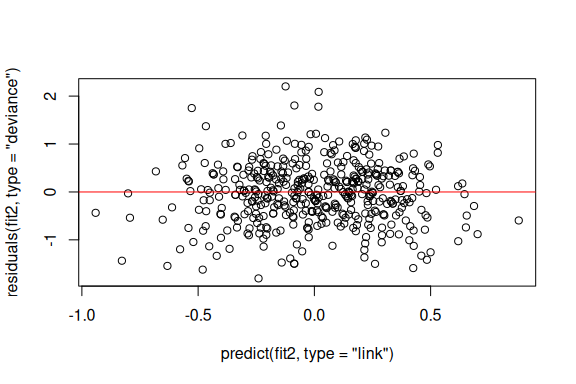

## Python

``` python
from scipy.stats import chi2

p_value = chi2.sf(180.2, df=449)  
print(p_value)
```

    1.0

``` python
linear_predictor = fit2.predict(linear=True)
deviance_residuals = fit2.resid_deviance

plt.figure(figsize=(6,4))
plt.scatter(linear_predictor, deviance_residuals)
plt.axhline(y=0)
plt.xlabel("Linear Predictor")
plt.ylabel("Deviance Residual")
plt.title("Deviance Residuals vs Linear Predictor")
plt.show()
```

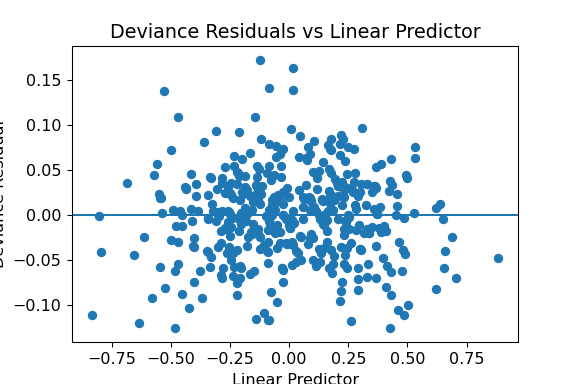

# 4.

Fitting a no-intercept logistic regression with log(RS) and log(RA) as
separate predictors yields $\hat{\beta}_1 = 1.753$ and
$\hat{\beta}_1=1.753$ and $\hat{\beta}_2 = -1.754$ This is consistent
with Parts 1 and 2, confirming that all three approaches produce
essentially the same estimate of $k \approx 1.753$.

## R

``` r
fit3 <- glm(WPct ~ log(RS) + log(RA) - 1,
            family = binomial,
            weights = G,
            data = TeamRuns)
summary(fit3)
```


    Call:
    glm(formula = WPct ~ log(RS) + log(RA) - 1, family = binomial, 
        data = TeamRuns, weights = G)

    Coefficients:
            Estimate Std. Error z value Pr(>|z|)    
    log(RS)  1.75314    0.04562   38.43   <2e-16 ***
    log(RA) -1.75355    0.04563  -38.43   <2e-16 ***
    ---
    Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

    (Dispersion parameter for binomial family taken to be 1)

        Null deviance: 1700.62  on 450  degrees of freedom
    Residual deviance:  180.14  on 448  degrees of freedom
    AIC: 2667.3

    Number of Fisher Scoring iterations: 3

## Python

``` python
fit3 = smf.glm(
  formula = "WPct ~ np.log(RS) + np.log(RA) -1",
  data = df,
  family = sm.families.Binomial(),
  freq_weights=df["G"]
).fit()

print(fit3.summary())
```

                     Generalized Linear Model Regression Results                  
    ==============================================================================
    Dep. Variable:                   WPct   No. Observations:                  420
    Model:                            GLM   Df Residuals:                    68028
    Model Family:                Binomial   Df Model:                            1
    Link Function:                  Logit   Scale:                          1.0000
    Method:                          IRLS   Log-Likelihood:                -30374.
    Date:                Wed, 10 Jun 2026   Deviance:                       165.58
    Time:                        05:36:03   Pearson chi2:                     165.
    No. Iterations:                     4   Pseudo R-squ. (CS):             0.9672
    Covariance Type:            nonrobust                                         
    ==============================================================================
                     coef    std err          z      P>|z|      [0.025      0.975]
    ------------------------------------------------------------------------------
    np.log(RS)     1.7607      0.047     37.355      0.000       1.668       1.853
    np.log(RA)    -1.7611      0.047    -37.355      0.000      -1.853      -1.669
    ==============================================================================

## 문제 2-2

`WPct`를 반응변수로, `logRS`, `logRA`, `H`, `X2B`, `X3B`, `HR`, `BB`,
`SO`, `CS`, `HBP`, `SF`, `ERA`, `CG`, `SHO`, `IPouts`, `HA`, `HRA`,
`BBA`, `SOA`, `E`, `DP`, `FP`, `SV`를 설명변수로 하는 절편항이 있는
로지스틱 회귀 모형을 적합하고 AIC를 기준으로 하는 단계별(stepwise)
변수선택을 적용하라. 변수선택 후 남은 변수들을 모두 모형에 남길지 일부를
제거할지 다시 판단하라. 최종적으로 선택된 모형을 문제1의 모형과
비교하라.

### 답안

## R

``` r
TeamRuns2 <- Teams %>%
  filter(2010 <= yearID & yearID <= 2025 & yearID != 2020) %>%
  rename(RS = R) %>%
  mutate(WPct = W / (W + L),
         run_ratio = RS/RA,
         logRS = log(RS),
         logRA = log(RA)) %>%
  select(WPct, run_ratio, W, G,
         logRS, logRA, H, X2B, X3B, HR, BB, SO, 
         CS, HBP, SF, ERA, CG, SHO, IPouts, HA, 
         HRA, BBA, SOA, E, DP, FP, SV)

fit_full <- glm(WPct ~.,
                family = binomial,
                weights = G,
                data = TeamRuns2)
summary(fit_full)
```


    Call:
    glm(formula = WPct ~ ., family = binomial, data = TeamRuns2, 
        weights = G)

    Coefficients:
                  Estimate Std. Error z value Pr(>|z|)    
    (Intercept) -3.130e-01  2.267e+01  -0.014    0.989    
    run_ratio   -8.863e-02  4.655e-01  -0.190    0.849    
    W            2.524e-02  2.590e-03   9.744   <2e-16 ***
    G           -1.324e-02  3.565e-02  -0.371    0.710    
    logRS        9.093e-02  5.328e-01   0.171    0.864    
    logRA       -6.963e-02  7.829e-01  -0.089    0.929    
    H           -4.748e-06  2.279e-04  -0.021    0.983    
    X2B          5.177e-06  4.242e-04   0.012    0.990    
    X3B          6.541e-05  1.040e-03   0.063    0.950    
    HR           8.023e-07  4.620e-04   0.002    0.999    
    BB           8.123e-06  1.965e-04   0.041    0.967    
    SO          -5.000e-06  9.121e-05  -0.055    0.956    
    CS          -3.466e-06  8.863e-04  -0.004    0.997    
    HBP         -7.841e-07  5.576e-04  -0.001    0.999    
    SF          -5.872e-05  1.154e-03  -0.051    0.959    
    ERA         -1.215e-03  1.197e-01  -0.010    0.992    
    CG          -1.111e-04  3.779e-03  -0.029    0.977    
    SHO         -7.496e-05  2.629e-03  -0.029    0.977    
    IPouts       8.459e-07  2.833e-04   0.003    0.998    
    HA          -1.817e-05  2.484e-04  -0.073    0.942    
    HRA         -1.693e-05  4.995e-04  -0.034    0.973    
    BBA         -1.088e-05  2.075e-04  -0.052    0.958    
    SOA         -2.915e-07  1.012e-04  -0.003    0.998    
    E            8.150e-05  3.573e-03   0.023    0.982    
    DP           3.380e-05  5.453e-04   0.062    0.951    
    FP           4.026e-01  2.172e+01   0.019    0.985    
    SV          -3.112e-05  1.824e-03  -0.017    0.986    
    ---
    Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

    (Dispersion parameter for binomial family taken to be 1)

        Null deviance: 1700.62081  on 449  degrees of freedom
    Residual deviance:    0.59236  on 423  degrees of freedom
    AIC: 2537.9

    Number of Fisher Scoring iterations: 3

## Python

``` python
TeamRuns2 = (
    pl.from_pandas(pylahman.Teams())
    .rename({
        "R": "RS",
        "2B": "X2B",
        "3B": "X3B"
    })
    .filter(
        (pl.col("yearID") >= 2010) &
        (pl.col("yearID") <= 2025) &
        (pl.col("yearID") != 2020)
    )
    .with_columns(
        (pl.col("W") / (pl.col("W") + pl.col("L"))).alias("WPct"),
        pl.col("RS").log().alias("logRS"),
        pl.col("RA").log().alias("logRA")
    )
    .select([
        "WPct",
        "logRS", "logRA",
        "H", "X2B", "X3B", "HR", "BB", "SO",
        "CS", "HBP", "SF",
        "ERA", "CG", "SHO", "IPouts",
        "HA", "HRA", "BBA", "SOA",
        "E", "DP", "FP", "SV",
        "G"
    ])
)
print(TeamRuns2.columns)
```

    ['WPct', 'logRS', 'logRA', 'H', 'X2B', 'X3B', 'HR', 'BB', 'SO', 'CS', 'HBP', 'SF', 'ERA', 'CG', 'SHO', 'IPouts', 'HA', 'HRA', 'BBA', 'SOA', 'E', 'DP', 'FP', 'SV', 'G']

``` python
df2 = TeamRuns2.to_pandas()
formula_full = """
WPct ~ logRS + logRA +
H + X2B + X3B + HR + BB + SO +
CS + HBP + SF +
ERA + CG + SHO + IPouts +
HA + HRA + BBA + SOA +
E + DP + FP + SV
"""
print(formula_full)
```


    WPct ~ logRS + logRA +
    H + X2B + X3B + HR + BB + SO +
    CS + HBP + SF +
    ERA + CG + SHO + IPouts +
    HA + HRA + BBA + SOA +
    E + DP + FP + SV

``` python
fit_full = smf.glm(
  formula = formula_full,
  data=df2,
  family=sm.families.Binomial(),
  freq_weights=df2["G"]
).fit()

print(fit_full.summary())
```

                     Generalized Linear Model Regression Results                  
    ==============================================================================
    Dep. Variable:                   WPct   No. Observations:                  420
    Model:                            GLM   Df Residuals:                    68006
    Model Family:                Binomial   Df Model:                           23
    Link Function:                  Logit   Scale:                          1.0000
    Method:                          IRLS   Log-Likelihood:                -30336.
    Date:                Wed, 10 Jun 2026   Deviance:                       89.524
    Time:                        05:36:03   Pearson chi2:                     89.5
    No. Iterations:                     4   Pseudo R-squ. (CS):             0.9726
    Covariance Type:            nonrobust                                         
    ==============================================================================
                     coef    std err          z      P>|z|      [0.025      0.975]
    ------------------------------------------------------------------------------
    Intercept     -5.5088     22.819     -0.241      0.809     -50.234      39.217
    logRS          1.7820      0.248      7.180      0.000       1.296       2.268
    logRA         -0.7697      0.474     -1.625      0.104      -1.698       0.159
    H             -0.0002      0.000     -0.793      0.428      -0.001       0.000
    X2B         8.553e-06      0.000      0.019      0.985      -0.001       0.001
    X3B           -0.0005      0.001     -0.415      0.678      -0.003       0.002
    HR            -0.0002      0.000     -0.389      0.697      -0.001       0.001
    BB            -0.0002      0.000     -0.990      0.322      -0.001       0.000
    SO         -7.812e-05   9.29e-05     -0.841      0.400      -0.000       0.000
    CS            -0.0011      0.001     -1.229      0.219      -0.003       0.001
    HBP         7.035e-05      0.001      0.121      0.903      -0.001       0.001
    SF            -0.0007      0.001     -0.622      0.534      -0.003       0.002
    ERA           -0.0269      0.118     -0.227      0.821      -0.259       0.205
    CG             0.0056      0.004      1.485      0.138      -0.002       0.013
    SHO            0.0038      0.003      1.427      0.153      -0.001       0.009
    IPouts         0.0004      0.000      1.411      0.158      -0.000       0.001
    HA            -0.0003      0.000     -1.312      0.189      -0.001       0.000
    HRA           -0.0006      0.001     -1.256      0.209      -0.002       0.000
    BBA           -0.0002      0.000     -0.766      0.444      -0.001       0.000
    SOA          3.81e-05      0.000      0.367      0.714      -0.000       0.000
    E             -0.0005      0.004     -0.146      0.884      -0.008       0.007
    DP             0.0005      0.001      0.869      0.385      -0.001       0.002
    FP            -2.1195     22.793     -0.093      0.926     -46.792      42.553
    SV             0.0108      0.001      7.466      0.000       0.008       0.014
    ==============================================================================

## 문제 2-3

1.  `W`(승리 횟수)를 반응변수로 하여 문제 2-2의 분석을 실시하되 포아송
    회귀모형을 사용하라. 결과를 문제 2-2의 모형과 비교하라.

2.  `W`를 반응변수로 하여 문제2의 분석을 실시하되 음이항 회귀모형을
    사용하라. 모형 적합 시 오류가 발생하면 이유를 파악해서 보고하라.

### 답안

# 1.

We use the model
$$\log(E[W]) = \log(G) +\beta_1 \cdot \log(run_ratio)$$

## R

``` r
fit3 <- glm(W~ log(run_ratio) -1 + offset(log(G)),
            family = poisson(),
            data = TeamRuns2)

summary(fit3)
```


    Call:
    glm(formula = W ~ log(run_ratio) - 1 + offset(log(G)), family = poisson(), 
        data = TeamRuns2)

    Coefficients:
                   Estimate Std. Error z value Pr(>|z|)    
    log(run_ratio)  0.40639    0.02216   18.34   <2e-16 ***
    ---
    Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

    (Dispersion parameter for poisson family taken to be 1)

        Null deviance: 23232  on 450  degrees of freedom
    Residual deviance: 22896  on 449  degrees of freedom
    AIC: 25698

    Number of Fisher Scoring iterations: 3

``` r
confint(fit3)
```

        2.5 %    97.5 % 
    0.3629425 0.4498204 

## Python

# 2.

## R

``` r
library(MASS)

fit_nb <- glm.nb(W ~ log(run_ratio) - 1 + offset(log(G)),
                 data = TeamRuns2)
summary(fit3)
```


    Call:
    glm(formula = W ~ log(run_ratio) - 1 + offset(log(G)), family = poisson(), 
        data = TeamRuns2)

    Coefficients:
                   Estimate Std. Error z value Pr(>|z|)    
    log(run_ratio)  0.40639    0.02216   18.34   <2e-16 ***
    ---
    Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

    (Dispersion parameter for poisson family taken to be 1)

        Null deviance: 23232  on 450  degrees of freedom
    Residual deviance: 22896  on 449  degrees of freedom
    AIC: 25698

    Number of Fisher Scoring iterations: 3

``` r
confint(fit3)
```

        2.5 %    97.5 % 
    0.3629425 0.4498204 

## Python

## 문제 2-4

스테로이드 시대인 1994년에서 2005년의 기간과 최근 시대인 2010년에서 2025
기간의 $k$ 계수가 유의하게 변화하는지 파악하기 위해 $i$번째 팀과 연도
$t$에 대해 다음과 같은 식을 생각해 볼 수 있다.
$$  WPct_(i,t)
  =
  \frac{1}{1+(RA_{i,t}/RS_{i,t} )^{k+g I(1994 \leq t \leq 2005)} }$$
이 때 $I(1994 \leq t \leq 2005)$는 괄호안의 조건이 만족되면 1의 값을
가지고 아니면 0의 값을 가지는 지시함수이고, $g$는 스테로이드 시대와 최근
시대의 차이를 나타내는 계수이다. 위의 식에서 $g$가 0과 유의하게 같은지
가설검정을 수행하게 해주는 로지스틱 모형을 적합하고 결과를 해석하라.
(코로나 시즌인 2020년은 제외한다.)

### 답안

The estimated difference between eras,
$\hat{g}=0.162 (95% CI: 0.015, 0.308)$, is statistically significant at
the $5\%$ level $(p=0.031)$, and its confidence interval excludes 0,
indicating that $k$ changed meaningfully between the two periods.

The steroid era (1994–2005) has a notably higher
$\hat{k} + \hat{g} = 1.753 + 0.162 = 1.915$ compared to the modern era
(2010–2025) where $\hat{k} \approx 1.753$, suggesting that the run ratio
(RA/RS) was a stronger predictor of WPct during the steroid era.

## R

``` r
TeamRuns4 <- Teams %>%
  filter((yearID >=1994 & yearID <=2005 | yearID>=2010 & yearID<=2025) & yearID != 2020) %>%
  rename(RS = R) %>%
  mutate(WPct = W / (W + L),
         run_ratio = RS/RA,
         steroid = ifelse(yearID >=1994 & yearID <=2005, 1, 0))  # indicator variable
fit_g <- glm(WPct ~ log(run_ratio) + I(steroid * log(run_ratio)) - 1,
             family = binomial,
             weights = G,
             data = TeamRuns4)
summary(fit_g)
```


    Call:
    glm(formula = WPct ~ log(run_ratio) + I(steroid * log(run_ratio)) - 
        1, family = binomial, data = TeamRuns4, weights = G)

    Coefficients:
                                Estimate Std. Error z value Pr(>|z|)    
    log(run_ratio)               1.75319    0.04562  38.434   <2e-16 ***
    I(steroid * log(run_ratio))  0.16159    0.07474   2.162   0.0306 *  
    ---
    Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

    (Dispersion parameter for binomial family taken to be 1)

        Null deviance: 2909.71  on 802  degrees of freedom
    Residual deviance:  315.73  on 800  degrees of freedom
    AIC: 4733.1

    Number of Fisher Scoring iterations: 3

``` r
confint(fit_g)
```

                                     2.5 %    97.5 %
    log(run_ratio)              1.66386800 1.8426805
    I(steroid * log(run_ratio)) 0.01514121 0.3081264

## Python

``` python
df4 = (
    pl.from_pandas(pylahman.Teams())
    .filter(
        (
            ((pl.col("yearID") >= 1994) & (pl.col("yearID") <= 2005)) |
            ((pl.col("yearID") >= 2010) & (pl.col("yearID") <= 2025))
        )
        & (pl.col("yearID") != 2020)
    )
    .rename({"R": "RS"})
    .with_columns([
        (pl.col("W") / (pl.col("W") + pl.col("L"))).alias("WPct"),
        (pl.col("RS") / pl.col("RA")).alias("run_ratio"),
        (pl.col("yearID").is_between(1994, 2005)).cast(pl.Int8).alias("steroid")
    ])
    .select(["WPct", "run_ratio", "G", "steroid"])
)
TeamRuns4 = df4.to_pandas()
TeamRuns4["log_run_ratio"] = np.log(TeamRuns4["run_ratio"])
TeamRuns4["interaction"] = TeamRuns4["steroid"] * TeamRuns4["log_run_ratio"]

fit_g = smf.glm(
    formula="WPct ~ log_run_ratio + interaction - 1",
    data=TeamRuns4,
    family=sm.families.Binomial(),
    freq_weights=TeamRuns4["G"]
).fit()
print(fit_g.summary())
```

                     Generalized Linear Model Regression Results                  
    ==============================================================================
    Dep. Variable:                   WPct   No. Observations:                  772
    Model:                            GLM   Df Residuals:                   123194
    Model Family:                Binomial   Df Model:                            1
    Link Function:                  Logit   Scale:                          1.0000
    Method:                          IRLS   Log-Likelihood:                -55030.
    Date:                Wed, 10 Jun 2026   Deviance:                       301.14
    Time:                        05:36:04   Pearson chi2:                     301.
    No. Iterations:                     4   Pseudo R-squ. (CS):             0.9612
    Covariance Type:            nonrobust                                         
    =================================================================================
                        coef    std err          z      P>|z|      [0.025      0.975]
    ---------------------------------------------------------------------------------
    log_run_ratio     1.7608      0.047     37.357      0.000       1.668       1.853
    interaction       0.1540      0.076      2.035      0.042       0.006       0.302
    =================================================================================

# 3부 데이터 분석 기술

숙제 2에서는 제출용 GitHub 저장소에 작업한 Quarto markdown 소스
파일(`hw02.qmd`)을 올리면 GitHub에서 자동으로 HTML 파일 및 주피터 노트북
파일(`.ipynb`)을 만들고 이것을 [GitHub
Pages](https://docs.github.com/en/pages/quickstart)에서 웹페이지로
보이도록 설정하였다. 여기서는 숙제 3 제출용 GibHub 저장소에 작업한
Quarto markdown 소스 파일(`hw03.qmd`)을 올리면 숙제 2에서의 작업
프로세스에 더해 자동 생성된 `.ipynb` 파일을 컨테이너화하여, GitHub에서
자동 생성된 컨테이너 이미지를 Binder 서비스를 이용하여 온라인에서 주피터
노트북 파일을 사용할 수 있도록 한다.

## 문제 3-1. Dockerfile 설정

로컬 저장소 최상위 디렉토리에 아래와 같은 `Dockerfile` 파일을 추가한다.

``` yaml
# 1. 기반 이미지 설정
FROM rocker/tidyverse:4.4.0

# 2. 시스템 의존성 설치 (ImageMagick 포함)
USER root
RUN apt-get update && apt-get install -y \
    wget \
    git \
    imagemagick \
    libmagick++-dev \
    && rm -rf /var/lib/apt/lists/*

# 3. Miniconda 설치
ENV CONDA_DIR /opt/conda
RUN wget --quiet https://repo.anaconda.com/miniconda/Miniconda3-latest-Linux-x86_64.sh -O ~/miniconda.sh && \
    /bin/bash ~/miniconda.sh -b -p /opt/conda && \
    rm ~/miniconda.sh

# 4. Conda 경로 설정 및 환경 생성
ENV PATH=$CONDA_DIR/bin:$PATH
RUN conda create -n r-reticulate python=3.10 -y && \
    conda install -n r-reticulate -c conda-forge numpy pandas matplotlib -y
# 추가로 필요한 패키지 설치

# 5. R 패키지 설치 (reticulate 및 필수 패키지)
RUN R -e "install.packages(c('reticulate', 'remotes', 'IRkernel'))" && \
    R -e "IRkernel::installspec(user = FALSE)"
# 추가로 필요한 패키지 설치

# 6. reticulate가 사용할 Python 경로 고정 (환경 변수)
ENV RETICULATE_PYTHON=/opt/conda/envs/r-reticulate/bin/python

# 7. (선택) Binder 사용자를 위한 권한 설정
# Binder는 보통 'jovyan' 유저 권한으로 실행
RUN chown -R ${NB_USER:-root} /opt/conda

# 기본 실행 경로 설정
WORKDIR /home/rstudio
```

### 답안

## 문제 3-2. GitHub Actions 워크플로우 수정

숙제 2에서 만들었던 `publish.yml`을 수정하여 기존의 배포 단계 끝에
Docker 컨테이너 이미지를 빌드하고 Github Container Registry (GHCR)에
푸시하는 단계를 추가한다.

``` yaml
# ... (기존 Quarto Render 단계 이후)

      - name: Log in to GitHub Container Registry
        uses: docker/login-action@v3
        with:
          registry: ghcr.io
          username: ${{ github.actor }}
          password: ${{ secrets.GITHUB_TOKEN }}

      - name: Build and push Docker image
        uses: docker/build-push-action@v5
        with:
          context: .
          push: true
          tags: ghcr.io/${{ github.repository_owner }}/my-r-env:latest
```

### 답안

## 문제 3-3. GitHub Pages에 Binder 링크 추가

GitHub Page를 사용하여 저장소를 웹페이지로 활용하는 부분은 숙제 2에서와
같다.

웹페이지에서 노트북을 내려받는 대신 [Binder](mybinder.org) 서비스를
이용하여 온라인으로 노트북을 실행할 수 있도록 위해 `README.md` 파일을
로컬 저장소 최상위 디렉토리에 다음과 같이 만들자.

``` markdown
# 숙제 3

이름: [아무개]
학번: [나의 학번]

이 숙제의 상세 분석 결과는 아래 링크에서 확인하실 수 있습니다.

* [분석 리포트 (HTML)](./hw03.html) 
* [주피터 노트북 (ipynb)](https://mybinder.org/v2/ghcr/<유저명>/my-r-env/latest?filepath=hw03.ipynb
```

여기서 `<유저명>`은 제출자의 GitHub 유저 아이디이다.

작업을 GitHub 원격 저장소로 push한 후 숙제 2 문제 3-3의 3, 4번 과정을
반복하라.

### 답안